<a href="https://colab.research.google.com/github/Evans-Sense/pet/blob/main/Hometask_5_MLPro2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import kagglehub
import os
from tqdm import tqdm
import torch

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.base import BaseEstimator

In [82]:
torch.manual_seed(42)

Описание/Пошаговая инструкция выполнения домашнего задания:
Используя PyTorch:

Создать и обучить регрессионную модель, которая аппроксимирует значение функции sin(x + 2*y)exp(-(2x + y)^2) на диапазоне значений [-10;10] по х и у.
В качестве обучающей выборки необходимо сгенерировать 20000 точек случайным образом.
Разделить получившийся датасет на train / test / val в отношениях 70% / 15% / 15%, соответственно.

Результаты:

a) Посчитать метрику Mean Square Error(MSE) на test.

b) Нарисовать график, в котором сравнивается истинная функция и ее аппроксимированный вариант (предсказываемый моделью).

In [83]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [84]:
num_points = 20000
min_val = -10.0
max_val = 10.0

df = torch.rand((num_points, 2) ).uniform_(-10,10)
x = df[:, 0]
y = df[:, 1]

df[:5]

tensor([[ 7.5913,  3.9456],
        [-5.2986,  0.5860],
        [ 4.7952,  0.2555],
        [ 5.9969,  9.9011],
        [-1.7026,  7.2349]])

In [85]:
input_size = 2
hidden_size = 32
num_epochs = 1000
batch_size = 64
learning_rate = 0.001

In [86]:
from torch.utils.data import DataLoader, random_split, TensorDataset
from sklearn.preprocessing import StandardScaler

def target_function(x, y):
    return torch.sin(x + 2 * y) * torch.exp(-(2 * x + y)**2)

z = target_function(df[:, 0], df[:, 1])

x_np = df.numpy()
z_np = z.numpy().reshape(-1, 1)

scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(x_np)

scaler_z = StandardScaler()
z_scaled = scaler_z.fit_transform(z_np)

df_scaled = torch.tensor(x_scaled, dtype=torch.float32)
z_scaled_tensor = torch.tensor(z_scaled, dtype=torch.float32)

dataset = torch.utils.data.TensorDataset(df_scaled, z_scaled_tensor)

# Определение соотношения разделения
train_size = int(0.7 * len(dataset))
eval_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - eval_size

# Разделение набора данных
train_dataset, eval_dataset, test_dataset = random_split(dataset, [train_size, eval_size, test_size])

# Создание DataLoader для каждого набора данных
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [87]:
import torch.nn as nn

class NeuralNetFC(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(NeuralNetFC, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size * 2)
        self.tanh1 = nn.Tanh()
        self.fc2 = nn.Linear(hidden_size * 2, hidden_size * 2)
        self.tanh2 = nn.Tanh()
        self.fc3 = nn.Linear(hidden_size * 2, hidden_size)
        self.tanh3 = nn.Tanh()
        self.fc4 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        out = self.fc1(x)
        out = self.tanh1(out)
        out = self.fc2(out)
        out = self.tanh2(out)
        out = self.fc3(out)
        out = self.tanh3(out)
        out = self.fc4(out)
        return out

In [89]:
model = NeuralNetFC(input_size, hidden_size).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

patience = 30
min_delta = 0.0001
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

total_step = len(train_loader)
print(f"Starting full training for {num_epochs} epochs...")

for epoch in tqdm(range(num_epochs)):
    model.train()
    train_losses = []
    for i, (input_data, target_data) in enumerate(train_loader):
        input_data = input_data.to(device)
        target_data = target_data.to(device)

        outputs = model(input_data)
        loss = criterion(outputs, target_data.view(-1, 1))
        train_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_train_loss = np.mean(train_losses)

    model.eval()
    val_losses = []
    with torch.no_grad():
        for input_data_val, target_data_val in eval_loader:
            input_data_val = input_data_val.to(device)
            target_data_val = target_data_val.to(device)
            outputs_val = model(input_data_val)
            val_loss = criterion(outputs_val, target_data_val.view(-1, 1))
            val_losses.append(val_loss.item())
    avg_val_loss = np.mean(val_losses)

    if (epoch % 10 == 0):
      print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss.")
            early_stop = True
            break

if not early_stop:
    print("Training completed without early stopping.")
else:
    print("Training stopped early.")

Starting full training for 1000 epochs...


  0%|          | 1/1000 [00:00<08:39,  1.92it/s]

Epoch [1/1000], Train Loss: 1.0135, Val Loss: 1.1917


  1%|          | 11/1000 [00:06<09:34,  1.72it/s]

Epoch [11/1000], Train Loss: 1.0070, Val Loss: 1.1887


...

Epoch [241/1000], Train Loss: 0.0130, Val Loss: 0.0258


 25%|██▌       | 251/1000 [02:14<06:23,  1.95it/s]

Epoch [251/1000], Train Loss: 0.0193, Val Loss: 0.0739


 25%|██▌       | 254/1000 [02:17<06:43,  1.85it/s]

Early stopping triggered after 255 epochs due to no improvement in validation loss.
Training stopped early.


In [90]:
from sklearn.metrics import mean_squared_error

model.eval()
with torch.no_grad():
    test_predicted_values_list = []
    test_actual_values_list = []
    for input_data, target_data in test_loader:
        input_data = input_data.to(device)
        target_data = target_data.to(device)
        outputs = model(input_data)
        test_predicted_values_list.append(outputs.cpu())
        test_actual_values_list.append(target_data.cpu())

    test_predicted_values = torch.cat(test_predicted_values_list).squeeze().numpy()
    test_actual_values = torch.cat(test_actual_values_list).numpy()

test_predicted_values_unscaled = scaler_z.inverse_transform(test_predicted_values.reshape(-1, 1))
test_actual_values_unscaled = scaler_z.inverse_transform(test_actual_values.reshape(-1, 1))

mse_unscaled = mean_squared_error(test_actual_values_unscaled, test_predicted_values_unscaled)
print(f"Mean Squared Error on Unscaled Test Set (after full training): {mse_unscaled:.4f}\n")


Mean Squared Error on Unscaled Test Set (after full training): 0.0003



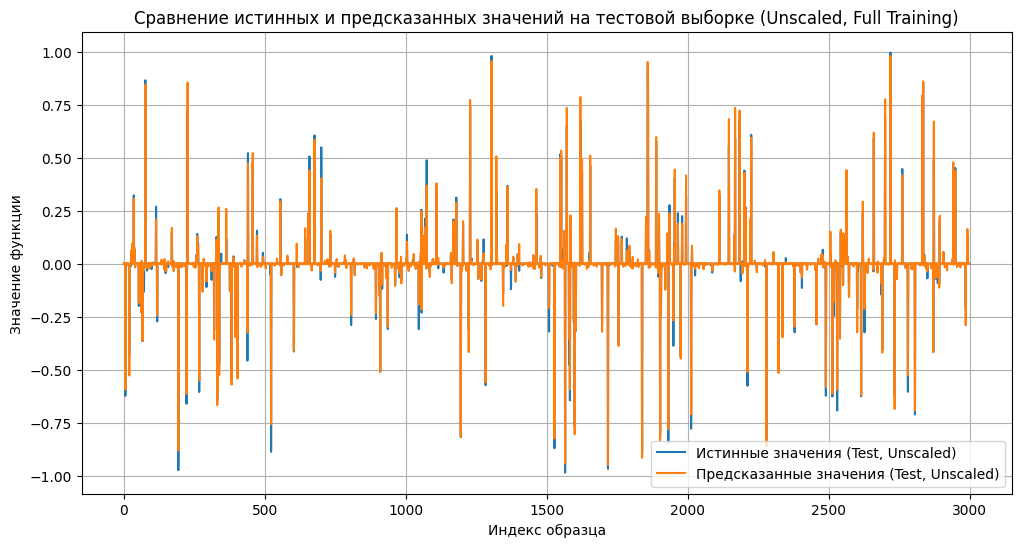

In [91]:
plt.figure(figsize=(12, 6))
plt.plot(test_actual_values_unscaled, label='Истинные значения (Test, Unscaled)')
plt.plot(test_predicted_values_unscaled, label='Предсказанные значения (Test, Unscaled)')
plt.title('Сравнение истинных и предсказанных значений на тестовой выборке (Unscaled, Full Training)')
plt.xlabel('Индекс образца')
plt.ylabel('Значение функции')
plt.legend()
plt.grid(True)
plt.show()